Wrote: rrc_sps4_beta0p35_span10_q16pcoe
taps: 41 (expected: 41 )
scale: 59809.511259187544
first 10 int taps: [ 224  -71 -348 -307   61  398  286 -286 -761 -442]


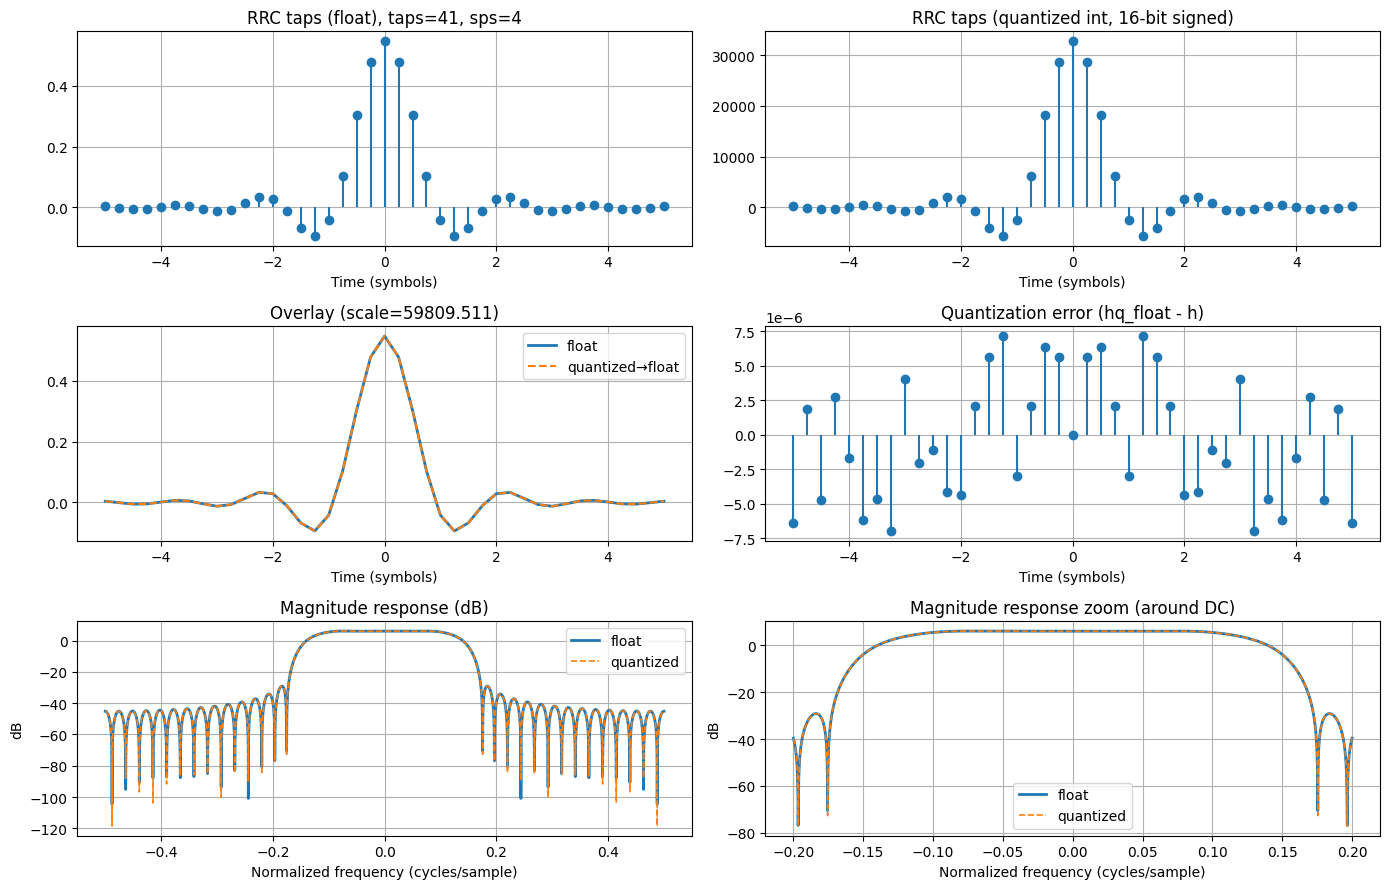

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rrc_filter(beta: float, span: int, sps: int) -> np.ndarray:
    """
    Root Raised Cosine (RRC) FIR impulse response
    beta: roll-off (0~1)
    span: filter length in symbols (total taps = span*sps + 1)
    sps : samples per symbol
    """
    N = span * sps
    t = np.arange(-N/2, N/2 + 1) / sps  # time in symbols
    h = np.zeros_like(t, dtype=np.float64)

    for i, ti in enumerate(t):
        if np.isclose(ti, 0.0):
            h[i] = 1.0 - beta + (4.0 * beta / np.pi)
        elif beta != 0 and np.isclose(abs(ti), 1.0 / (4.0 * beta)):
            h[i] = (beta / np.sqrt(2.0)) * (
                (1.0 + 2.0/np.pi) * np.sin(np.pi / (4.0*beta)) +
                (1.0 - 2.0/np.pi) * np.cos(np.pi / (4.0*beta))
            )
        else:
            num = np.sin(np.pi * ti * (1.0 - beta)) + 4.0 * beta * ti * np.cos(np.pi * ti * (1.0 + beta))
            den = np.pi * ti * (1.0 - (4.0 * beta * ti)**2)
            h[i] = num / den

    # energy normalize
    h /= np.sqrt(np.sum(h*h))
    return h

def quantize_to_int(h: np.ndarray, coef_bits: int = 16):
    """
    Scale by max-abs so the largest |tap| uses full-scale.
    Returns:
      hq: int coefficients
      scale: float scale factor (hq ~= h*scale)
      hq_float: back-converted float (= hq/scale)
    """
    maxv = np.max(np.abs(h))
    full = (2**(coef_bits-1) - 1)
    scale = full / maxv
    hq = np.round(h * scale).astype(np.int64)
    hq = np.clip(hq, -2**(coef_bits-1), 2**(coef_bits-1)-1).astype(np.int64)
    hq_float = hq.astype(np.float64) / scale
    return hq, scale, hq_float

def write_coe(path: str, coeff_int: np.ndarray, radix: int = 10):
    with open(path, "w", encoding="utf-8") as f:
        f.write(f"radix={radix};\n")
        f.write("coefdata=\n")
        for k, c in enumerate(coeff_int):
            end = "," if k < len(coeff_int)-1 else ";"
            f.write(f"{int(c)}{end}\n")

def plot_rrc(h: np.ndarray, hq_int: np.ndarray, hq_float: np.ndarray, sps: int, scale: float):
    taps = len(h)
    n = np.arange(taps)
    t_sym = (n - (taps-1)/2) / sps  # time axis in symbols (centered)

    # Frequency response (normalized frequency: cycles/sample)
    Nfft = 8192
    H  = np.fft.fftshift(np.fft.fft(h, Nfft))
    Hq = np.fft.fftshift(np.fft.fft(hq_float, Nfft))
    f = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1.0))  # -0.5..0.5 cycles/sample

    eps = 1e-12
    mag_db  = 20*np.log10(np.abs(H)  + eps)
    magq_db = 20*np.log10(np.abs(Hq) + eps)

    err = hq_float - h

    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 9))

    # (1) Time-domain taps (float)
    ax1 = plt.subplot(3, 2, 1)
    ax1.stem(t_sym, h, basefmt=" ")
    ax1.set_title(f"RRC taps (float), taps={taps}, sps={sps}")
    ax1.set_xlabel("Time (symbols)")
    ax1.grid(True)

    # (2) Time-domain taps (int)
    ax2 = plt.subplot(3, 2, 2)
    ax2.stem(t_sym, hq_int, basefmt=" ")
    ax2.set_title("RRC taps (quantized int, 16-bit signed)")
    ax2.set_xlabel("Time (symbols)")
    ax2.grid(True)

    # (3) Overlay float vs quantized-back-to-float
    ax3 = plt.subplot(3, 2, 3)
    ax3.plot(t_sym, h, label="float", linewidth=2)
    ax3.plot(t_sym, hq_float, "--", label="quantized→float", linewidth=1.5)
    ax3.set_title(f"Overlay (scale={scale:.3f})")
    ax3.set_xlabel("Time (symbols)")
    ax3.grid(True)
    ax3.legend()

    # (4) Quantization error
    ax4 = plt.subplot(3, 2, 4)
    ax4.stem(t_sym, err, basefmt=" ")
    ax4.set_title("Quantization error (hq_float - h)")
    ax4.set_xlabel("Time (symbols)")
    ax4.grid(True)

    # (5) Frequency response magnitude
    ax5 = plt.subplot(3, 2, 5)
    ax5.plot(f, mag_db, label="float", linewidth=2)
    ax5.plot(f, magq_db, "--", label="quantized", linewidth=1.2)
    ax5.set_title("Magnitude response (dB)")
    ax5.set_xlabel("Normalized frequency (cycles/sample)")
    ax5.set_ylabel("dB")
    ax5.grid(True)
    ax5.legend()

    # (6) Zoomed-in passband
    ax6 = plt.subplot(3, 2, 6)
    mask = (f >= -0.2) & (f <= 0.2)
    ax6.plot(f[mask], mag_db[mask], label="float", linewidth=2)
    ax6.plot(f[mask], magq_db[mask], "--", label="quantized", linewidth=1.2)
    ax6.set_title("Magnitude response zoom (around DC)")
    ax6.set_xlabel("Normalized frequency (cycles/sample)")
    ax6.set_ylabel("dB")
    ax6.grid(True)
    ax6.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # ===== Parameters (너가 정한 조건) =====
    sps = 4
    beta = 0.35
    span = 10
    coef_bits = 16

    # Generate taps
    h = rrc_filter(beta=beta, span=span, sps=sps)

    # Quantize
    hq_int, scale, hq_float = quantize_to_int(h, coef_bits=coef_bits)

    # Write COE
    fname = f"rrc_sps{sps}_beta{beta}_span{span}_q{coef_bits}.coe".replace(".", "p")
    write_coe(fname, hq_int, radix=10)

    print("Wrote:", fname)
    print("taps:", len(h), "(expected:", span*sps + 1, ")")
    print("scale:", scale)
    print("first 10 int taps:", hq_int[:10])

    # Plot
    plot_rrc(h, hq_int, hq_float, sps=sps, scale=scale)